<a href="https://colab.research.google.com/github/zainmorshed/Stock_Price_Prediction/blob/main/Zain_Morshed_Stock_Price_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import yfinance as yf

In [ ]:
sp500 = yf.Ticker('^GSPC')


In [ ]:
sp500 = sp500.history(period='max')

In [ ]:
sp500

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
1927-12-30 00:00:00-05:00,17.660000,17.660000,17.660000,17.660000,0,0.0,0.0
1928-01-03 00:00:00-05:00,17.760000,17.760000,17.760000,17.760000,0,0.0,0.0
1928-01-04 00:00:00-05:00,17.719999,17.719999,17.719999,17.719999,0,0.0,0.0
1928-01-05 00:00:00-05:00,17.549999,17.549999,17.549999,17.549999,0,0.0,0.0
1928-01-06 00:00:00-05:00,17.660000,17.660000,17.660000,17.660000,0,0.0,0.0
...,...,...,...,...,...,...,...
2024-11-14 00:00:00-05:00,5989.680176,5993.879883,5942.279785,5949.169922,4184570000,0.0,0.0
2024-11-15 00:00:00-05:00,5912.790039,5915.319824,5853.009766,5870.620117,4590960000,0.0,0.0
2024-11-18 00:00:00-05:00,5874.169922,5908.120117,5865.950195,5893.620117,3983860000,0.0,0.0


In [ ]:
sp500.index

DatetimeIndex(['1927-12-30 00:00:00-05:00', '1928-01-03 00:00:00-05:00',
               '1928-01-04 00:00:00-05:00', '1928-01-05 00:00:00-05:00',
               '1928-01-06 00:00:00-05:00', '1928-01-09 00:00:00-05:00',
               '1928-01-10 00:00:00-05:00', '1928-01-11 00:00:00-05:00',
               '1928-01-12 00:00:00-05:00', '1928-01-13 00:00:00-05:00',
               ...
               '2024-11-07 00:00:00-05:00', '2024-11-08 00:00:00-05:00',
               '2024-11-11 00:00:00-05:00', '2024-11-12 00:00:00-05:00',
               '2024-11-13 00:00:00-05:00', '2024-11-14 00:00:00-05:00',
               '2024-11-15 00:00:00-05:00', '2024-11-18 00:00:00-05:00',
               '2024-11-19 00:00:00-05:00', '2024-11-20 00:00:00-05:00'],
              dtype='datetime64[ns, America/New_York]', name='Date', length=24340, freq=None)

<Axes: xlabel='Date'>

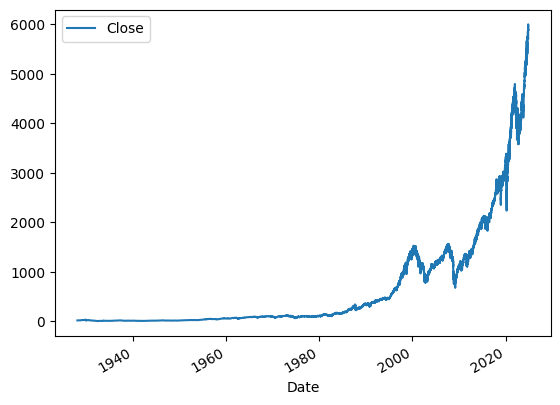

In [ ]:
sp500.plot.line(y='Close', use_index=True)

In [ ]:
del sp500['Dividends']
del sp500['Stock Splits']

In [ ]:
sp500['Tommorow'] = sp500['Close'].shift(-1)

In [ ]:
sp500

,Open,High,Low,Close,Volume,Tommorow
Date,,,,,,
1927-12-30 00:00:00-05:00,17.660000,17.660000,17.660000,17.660000,0,17.760000
1928-01-03 00:00:00-05:00,17.760000,17.760000,17.760000,17.760000,0,17.719999
1928-01-04 00:00:00-05:00,17.719999,17.719999,17.719999,17.719999,0,17.549999
1928-01-05 00:00:00-05:00,17.549999,17.549999,17.549999,17.549999,0,17.660000
1928-01-06 00:00:00-05:00,17.660000,17.660000,17.660000,17.660000,0,17.500000
...,...,...,...,...,...,...
2024-11-14 00:00:00-05:00,5989.680176,5993.879883,5942.279785,5949.169922,4184570000,5870.620117
2024-11-15 00:00:00-05:00,5912.790039,5915.319824,5853.009766,5870.620117,4590960000,5893.620117
2024-11-18 00:00:00-05:00,5874.169922,5908.120117,5865.950195,5893.620117,3983860000,5916.979980


In [ ]:
sp500['Target'] = (sp500['Tommorow'] > sp500['Close']).astype(int)

In [ ]:
sp500

,Open,High,Low,Close,Volume,Tommorow,Target
Date,,,,,,,
1927-12-30 00:00:00-05:00,17.660000,17.660000,17.660000,17.660000,0,17.760000,1
1928-01-03 00:00:00-05:00,17.760000,17.760000,17.760000,17.760000,0,17.719999,0
1928-01-04 00:00:00-05:00,17.719999,17.719999,17.719999,17.719999,0,17.549999,0
1928-01-05 00:00:00-05:00,17.549999,17.549999,17.549999,17.549999,0,17.660000,1
1928-01-06 00:00:00-05:00,17.660000,17.660000,17.660000,17.660000,0,17.500000,0
...,...,...,...,...,...,...,...
2024-11-14 00:00:00-05:00,5989.680176,5993.879883,5942.279785,5949.169922,4184570000,5870.620117,0
2024-11-15 00:00:00-05:00,5912.790039,5915.319824,5853.009766,5870.620117,4590960000,5893.620117,1
2024-11-18 00:00:00-05:00,5874.169922,5908.120117,5865.950195,5893.620117,3983860000,5916.979980,1


In [ ]:
sp500 = sp500.loc['1990-01-01':].copy()

In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100, min_samples_split=100, random_state=1)
train = sp500.iloc[:-100]
test = sp500.iloc[-100:]

predictors = ['Close', 'Volume', 'Open', 'High', 'Low']
model.fit(train[predictors], train['Target'])

RandomForestClassifier(min_samples_split=100, random_state=1)

In [ ]:
from sklearn.metrics import precision_score

import pandas as pd

preds = model.predict(test[predictors])
preds = pd.Series(preds, index=test.index)
precision_score(test['Target'], preds)

0.7222222222222222

In [ ]:
combined = pd.concat([test['Target'],preds], axis=1)

<Axes: xlabel='Date'>

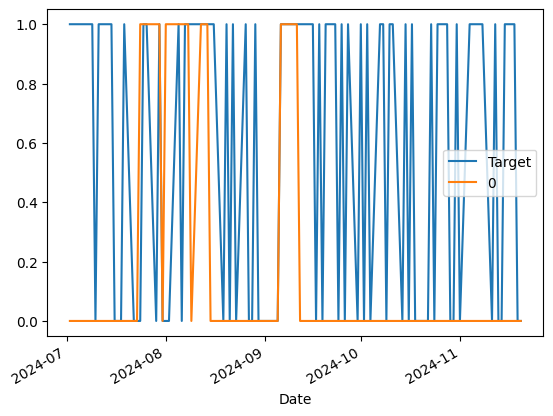

In [ ]:
combined.plot()

In [ ]:
def predict(train, test, predictors, model):
  model.fit(train[predictors], train['Target'])
  preds = model.predict(test[predictors])
  preds = pd.Series(preds, index=test.index, name='Predictions')
  combined = pd.concat([test['Target'], preds], axis=1)
  return combined

In [ ]:
import pandas as pd

def backtest(data, model, predictors, start=2500, step=250):
    all_predictions = []

    for i in range(start, data.shape[0], step):
        train = data.iloc[0:i].copy()
        test = data.iloc[i:(i + step)].copy()

        predictions = predict(train, test, predictors, model)

        all_predictions.append(predictions)


    return pd.concat(all_predictions)

predictions = backtest(sp500, model, predictors)

predictions['Predictions'].value_counts()
precision_score(predictions['Target'], predictions['Predictions'])
predictions['Target'].value_counts() / predictions.shape[0]

,count
Target,
1,0.535771
0,0.464229


In [ ]:
horizons = [2,5,60,250,1000]
new_predictors = []

for horizon in horizons:
  rolling_averages = sp500.rolling(horizon).mean()

  ratio_column = f"Close_Ratio_{horizon}"
  sp500[ratio_column] = sp500['Close'] / rolling_averages['Close']

  trend_column = f"Trend_{horizon}"
  sp500[trend_column] = sp500.shift(1).rolling(horizon).sum()['Target']

  new_predictors += [ratio_column, trend_column]

In [ ]:
sp500

,Open,High,Low,Close,Volume,Tommorow,Target,Close_Ratio_2,Trend_2,Close_Ratio_5,Trend_5,Close_Ratio_60,Trend_60,Close_Ratio_250,Trend_250,Close_Ratio_1000,Trend_1000
Date,,,,,,,,,,,,,,,,,
1990-01-02 00:00:00-05:00,353.399994,359.690002,351.980011,359.690002,162070000,358.760010,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1990-01-03 00:00:00-05:00,359.690002,360.589996,357.890015,358.760010,192330000,355.670013,0,0.998706,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1990-01-04 00:00:00-05:00,358.760010,358.760010,352.890015,355.670013,177000000,352.200012,0,0.995675,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1990-01-05 00:00:00-05:00,355.670013,355.670013,351.350006,352.200012,158530000,353.790009,1,0.995098,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1990-01-08 00:00:00-05:00,352.200012,354.239990,350.540009,353.790009,140110000,349.619995,0,1.002252,1.0,0.993731,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-11-14 00:00:00-05:00,5989.680176,5993.879883,5942.279785,5949.169922,4184570000,5870.620117,0,0.996966,1.0,0.994331,3.0,1.037734,33.0,1.129501,146.0,1.335540,528.0
2024-11-15 00:00:00-05:00,5912.790039,5915.319824,5853.009766,5870.620117,4590960000,5893.620117,1,0.993354,0.0,0.985317,2.0,1.023140,33.0,1.113440,145.0,1.317246,527.0
2024-11-18 00:00:00-05:00,5874.169922,5908.120117,5865.950195,5893.620117,3983860000,5916.979980,1,1.001955,1.0,0.992768,2.0,1.026376,33.0,1.116662,145.0,1.321735,528.0


In [ ]:
sp500 = sp500.dropna()
sp500

,Open,High,Low,Close,Volume,Tommorow,Target,Close_Ratio_2,Trend_2,Close_Ratio_5,Trend_5,Close_Ratio_60,Trend_60,Close_Ratio_250,Trend_250,Close_Ratio_1000,Trend_1000
Date,,,,,,,,,,,,,,,,,
1993-12-14 00:00:00-05:00,465.730011,466.119995,462.459991,463.059998,275050000,461.839996,0,0.997157,1.0,0.996617,1.0,1.000283,32.0,1.028047,127.0,1.176082,512.0
1993-12-15 00:00:00-05:00,463.059998,463.690002,461.839996,461.839996,331770000,463.339996,1,0.998681,0.0,0.995899,1.0,0.997329,32.0,1.025151,126.0,1.172676,512.0
1993-12-16 00:00:00-05:00,461.859985,463.980011,461.859985,463.339996,284620000,466.380005,1,1.001621,1.0,0.999495,2.0,1.000311,32.0,1.028274,127.0,1.176163,513.0
1993-12-17 00:00:00-05:00,463.339996,466.380005,463.339996,466.380005,363750000,465.850006,0,1.003270,2.0,1.004991,3.0,1.006561,32.0,1.034781,128.0,1.183537,514.0
1993-12-20 00:00:00-05:00,466.380005,466.899994,465.529999,465.850006,255900000,465.299988,0,0.999431,1.0,1.003784,2.0,1.005120,32.0,1.033359,128.0,1.181856,513.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-11-13 00:00:00-05:00,5985.750000,6008.189941,5965.910156,5985.379883,4220180000,5949.169922,0,1.000116,1.0,0.999584,4.0,1.045048,34.0,1.137620,147.0,1.344385,529.0
2024-11-14 00:00:00-05:00,5989.680176,5993.879883,5942.279785,5949.169922,4184570000,5870.620117,0,0.996966,1.0,0.994331,3.0,1.037734,33.0,1.129501,146.0,1.335540,528.0
2024-11-15 00:00:00-05:00,5912.790039,5915.319824,5853.009766,5870.620117,4590960000,5893.620117,1,0.993354,0.0,0.985317,2.0,1.023140,33.0,1.113440,145.0,1.317246,527.0


In [ ]:
model = RandomForestClassifier(n_estimators=200, min_samples_split=500, random_state=1)

In [ ]:
def predict(train, test, predictors, model):
  model.fit(train[predictors], train['Target'])
  preds = model.predict_proba(test[predictors])[:,1]
  preds[preds>= .6] = 1
  preds[preds<.6] = 0
  preds = pd.Series(preds, index=test.index, name='Predictions')
  combined = pd.concat([test['Target'], preds], axis=1)
  return combined


In [ ]:
predictions = backtest(sp500, model, new_predictors)

In [ ]:
predictions['Predictions'].value_counts()

,count
Predictions,
0.0,5116
1.0,173


In [ ]:
precision_score(predictions['Target'], predictions['Predictions'])

0.6242774566473989